# PROYECTO FINAL MODULO 5: ENTRENAMIENTO DE MODELO DE MACHINE LEARNING PARA DETERMINAR SI UN PACIENTE SUFRE DE ANEMIA

## FUENTE : [DATOS ABIERTOS](https://www.datosabiertos.gob.pe/dataset/morbilidad-anemia)

### Autor: Mario Paucar Oscanoa

In [221]:
!pip install pyjanitor
import janitor


[notice] A new release of pip available: 22.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [222]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [223]:
DATASET_PATH = "D:\Conocimiento Adquiridos\Data Science _ Codigo Bootcamp\Desarrollo_MP\BDS-G3\Proyecto_Modulo5\DATASET\TB_ANEMIA.csv"
df_anemia = pd.read_csv(DATASET_PATH,sep = ";")
df_anemia.head(10)

<>:1: DeprecationWarning: invalid escape sequence '\C'
<>:1: DeprecationWarning: invalid escape sequence '\C'
C:\Users\ingma\AppData\Local\Temp\ipykernel_24968\2802155508.py:1: DeprecationWarning: invalid escape sequence '\C'
  DATASET_PATH = "D:\Conocimiento Adquiridos\Data Science _ Codigo Bootcamp\Desarrollo_MP\BDS-G3\Proyecto_Modulo5\DATASET\TB_ANEMIA.csv"


,id_persona,Edad,Tipo_edad,Sexo,id_ubigeo,Fecha_atencion,Diagnostico,Tipo_Dx,id_eess
0,40971314,2,A,M,NaN,20230522,D649,D,6203
1,39270343,4,A,M,1128.0,20211122,D509,D,10836
2,39270343,4,A,M,1128.0,20211129,D509,D,10836
3,39155787,3,A,F,1128.0,20210527,D509,D,10836
4,36178995,2,A,F,1299.0,20210215,D509,D,6079
5,38926264,4,A,M,1506.0,20211113,D509,D,7475
6,39141175,1,A,M,1128.0,20210220,D509,D,6856
7,40229751,2,A,M,1278.0,20221120,D509,D,4416
8,39603123,1,A,M,1278.0,20210428,D509,D,4416
9,39105165,1,A,M,1128.0,20210106,D509,D,10836


# EDA

In [224]:
df_anemia.shape

(1327924, 9)

In [225]:
df_anemia.dtypes

id_persona          int64
Edad                int64
Tipo_edad          object
Sexo               object
id_ubigeo         float64
Fecha_atencion      int64
Diagnostico        object
Tipo_Dx            object
id_eess             int64
dtype: object

# TRATAMIENTO DE NULOS

In [226]:
df_anemia.isnull().sum().sum()

10817

In [227]:
df_anemia.isnull().sum()

id_persona            0
Edad                  0
Tipo_edad             0
Sexo                  0
id_ubigeo         10817
Fecha_atencion        0
Diagnostico           0
Tipo_Dx               0
id_eess               0
dtype: int64

In [228]:
df_anemia.dropna(subset=['id_ubigeo'],inplace=True)
df_anemia.shape

(1317107, 9)

# TRATAMIENTO DE DUPLICADOS

In [229]:
df_anemia.duplicated().sum()

19287

In [230]:
df_anemia[df_anemia.duplicated()]

,id_persona,Edad,Tipo_edad,Sexo,id_ubigeo,Fecha_atencion,Diagnostico,Tipo_Dx,id_eess
329,38985611,1,A,F,26.0,20210716,D509,D,5081
369,38942468,1,A,M,42.0,20210627,D509,D,5183
610,38954543,2,A,F,42.0,20211210,D509,D,5180
612,38954543,2,A,F,42.0,20211110,D509,D,5180
827,39153550,2,A,F,26.0,20220329,D509,D,6977
...,...,...,...,...,...,...,...,...,...
1327513,35766370,2,A,F,1283.0,20210820,D509,D,5882
1327576,26591876,2,A,F,675.0,20211108,D509,D,4574
1327624,23789774,1,A,F,1288.0,20210309,D509,D,5995
1327878,33283345,4,A,M,1414.0,20240120,D509,D,5656


In [231]:
df_anemia.drop_duplicates(keep='first',inplace=True)
df_anemia.shape

(1297820, 9)

# ANALIZANDO VARIABLES

## ELIMINAMOS ID_PERSONA

In [232]:
df_anemia.drop(['id_persona'],axis=1,inplace=True)
df_anemia.head(10)

,Edad,Tipo_edad,Sexo,id_ubigeo,Fecha_atencion,Diagnostico,Tipo_Dx,id_eess
1,4,A,M,1128.0,20211122,D509,D,10836
2,4,A,M,1128.0,20211129,D509,D,10836
3,3,A,F,1128.0,20210527,D509,D,10836
4,2,A,F,1299.0,20210215,D509,D,6079
5,4,A,M,1506.0,20211113,D509,D,7475
6,1,A,M,1128.0,20210220,D509,D,6856
7,2,A,M,1278.0,20221120,D509,D,4416
8,1,A,M,1278.0,20210428,D509,D,4416
9,1,A,M,1128.0,20210106,D509,D,10836
10,1,A,M,1128.0,20210107,D509,D,10836


# CONVERTIMOS DATA  DE EDAD A AÑOS

In [233]:
df_anemia.Tipo_edad.value_counts()

A    920953
M    375857
D      1010
Name: Tipo_edad, dtype: int64

In [234]:
df_anemia['edad_total'] = np.where(
    df_anemia['Tipo_edad'] == 'M', df_anemia['Edad'] / 12,
    np.where(df_anemia['Tipo_edad'] == 'D', df_anemia['Edad'] / 365, df_anemia['Edad'])
)
df_anemia[df_anemia['Tipo_edad']=='D'].head(10)

,Edad,Tipo_edad,Sexo,id_ubigeo,Fecha_atencion,Diagnostico,Tipo_Dx,id_eess,edad_total
1775,1,D,F,1477.0,20210106,D509,D,125,0.002740
4616,1,D,F,1128.0,20210531,D509,D,10836,0.002740
5149,20,D,M,994.0,20210608,D539,D,3364,0.054795
6450,6,D,F,1464.0,20210213,D509,D,212,0.016438
6694,1,D,M,774.0,20220225,D509,D,2435,0.002740
6740,24,D,F,1866.0,20210423,D509,D,5513,0.065753
7054,1,D,M,1460.0,20210805,D509,D,16,0.002740
7144,9,D,F,1274.0,20211204,D509,D,4432,0.024658
7177,17,D,F,1248.0,20220322,D509,D,4327,0.046575
7248,16,D,M,1484.0,20210308,D500,D,146,0.043836


# ANALIZAMOS ID_UBIGEO

In [235]:
df_anemia['id_ubigeo'].value_counts()

1312.0    33487
1283.0    20689
1290.0    13846
1863.0    13049
1323.0    13029
          ...  
1842.0        1
320.0         1
1841.0        1
190.0         1
1890.0        1
Name: id_ubigeo, Length: 1868, dtype: int64

In [236]:
PATH_UBIGEOS = "D:\Conocimiento Adquiridos\Data Science _ Codigo Bootcamp\Desarrollo_MP\BDS-G3\Proyecto_Modulo5\DATASET\TB_UBIGEOS.csv"
df_ubigeos = pd.read_csv(PATH_UBIGEOS,sep=';')
df_ubigeos.head(10)

<>:1: DeprecationWarning: invalid escape sequence '\C'
<>:1: DeprecationWarning: invalid escape sequence '\C'
C:\Users\ingma\AppData\Local\Temp\ipykernel_24968\1910342920.py:1: DeprecationWarning: invalid escape sequence '\C'
  PATH_UBIGEOS = "D:\Conocimiento Adquiridos\Data Science _ Codigo Bootcamp\Desarrollo_MP\BDS-G3\Proyecto_Modulo5\DATASET\TB_UBIGEOS.csv"


,id_ubigeo,ubigeo_reniec,ubigeo_inei,departamento_inei,departamento,provincia_inei,provincia,distrito,region,macroregion_inei,macroregion_minsa,iso_3166_2,fips,superficie,altitud,latitud,longitud,Frontera
0,1,10101.0,10101,1,AMAZONAS,101,CHACHAPOYAS,CHACHAPOYAS,AMAZONAS,ORIENTE,MACROREGION ORIENTE,PE-AMA,1,154.0,2338.0,-6.2294,-77.8728,NO
1,2,10102.0,10102,1,AMAZONAS,101,CHACHAPOYAS,ASUNCION,AMAZONAS,ORIENTE,MACROREGION ORIENTE,PE-AMA,1,26.0,2823.0,-6.0325,-77.7108,NO
2,3,10103.0,10103,1,AMAZONAS,101,CHACHAPOYAS,BALSAS,AMAZONAS,ORIENTE,MACROREGION ORIENTE,PE-AMA,1,357.0,859.0,-6.8358,-78.0197,NO
3,4,10104.0,10104,1,AMAZONAS,101,CHACHAPOYAS,CHETO,AMAZONAS,ORIENTE,MACROREGION ORIENTE,PE-AMA,1,57.0,2143.0,-6.2556,-77.7008,NO
4,5,10105.0,10105,1,AMAZONAS,101,CHACHAPOYAS,CHILIQUIN,AMAZONAS,ORIENTE,MACROREGION ORIENTE,PE-AMA,1,143.0,2677.0,-6.0783,-77.7375,NO
5,6,10106.0,10106,1,AMAZONAS,101,CHACHAPOYAS,CHUQUIBAMBA,AMAZONAS,ORIENTE,MACROREGION ORIENTE,PE-AMA,1,279.0,2803.0,-6.9350,-77.8542,NO
6,7,10107.0,10107,1,AMAZONAS,101,CHACHAPOYAS,GRANADA,AMAZONAS,ORIENTE,MACROREGION ORIENTE,PE-AMA,1,181.0,3041.0,-6.1064,-77.6286,NO
7,8,10108.0,10108,1,AMAZONAS,101,CHACHAPOYAS,HUANCAS,AMAZONAS,ORIENTE,MACROREGION ORIENTE,PE-AMA,1,49.0,2591.0,-6.1736,-77.8644,NO
8,9,10109.0,10109,1,AMAZONAS,101,CHACHAPOYAS,LA JALCA,AMAZONAS,ORIENTE,MACROREGION ORIENTE,PE-AMA,1,380.0,2869.0,-6.4847,-77.8150,NO
9,10,10110.0,10110,1,AMAZONAS,101,CHACHAPOYAS,LEIMEBAMBA,AMAZONAS,ORIENTE,MACROREGION ORIENTE,PE-AMA,1,373.0,2226.0,-6.7075,-77.8039,NO


In [237]:
df_anemia_ubigeo = df_ubigeos[['id_ubigeo','departamento']].copy()
df_anemia_ubigeo.head()

,id_ubigeo,departamento
0,1,AMAZONAS
1,2,AMAZONAS
2,3,AMAZONAS
3,4,AMAZONAS
4,5,AMAZONAS


In [238]:
df_anemia = df_anemia.merge(df_anemia_ubigeo,on='id_ubigeo',how='left')
df_anemia.head(10)

,Edad,Tipo_edad,Sexo,id_ubigeo,Fecha_atencion,Diagnostico,Tipo_Dx,id_eess,edad_total,departamento
0,4,A,M,1128.0,20211122,D509,D,10836,4.0,JUNIN
1,4,A,M,1128.0,20211129,D509,D,10836,4.0,JUNIN
2,3,A,F,1128.0,20210527,D509,D,10836,3.0,JUNIN
3,2,A,F,1299.0,20210215,D509,D,6079,2.0,LIMA
4,4,A,M,1506.0,20211113,D509,D,7475,4.0,MADRE DE DIOS
5,1,A,M,1128.0,20210220,D509,D,6856,1.0,JUNIN
6,2,A,M,1278.0,20221120,D509,D,4416,2.0,LAMBAYEQUE
7,1,A,M,1278.0,20210428,D509,D,4416,1.0,LAMBAYEQUE
8,1,A,M,1128.0,20210106,D509,D,10836,1.0,JUNIN
9,1,A,M,1128.0,20210107,D509,D,10836,1.0,JUNIN


In [239]:
df_anemia['cie10'] = np.where(df_anemia['Diagnostico'].str.startswith(('D50','D53','D64')),1,0)

In [240]:
df_anemia.head(3)

,Edad,Tipo_edad,Sexo,id_ubigeo,Fecha_atencion,Diagnostico,Tipo_Dx,id_eess,edad_total,departamento,cie10
0,4,A,M,1128.0,20211122,D509,D,10836,4.0,JUNIN,1
1,4,A,M,1128.0,20211129,D509,D,10836,4.0,JUNIN,1
2,3,A,F,1128.0,20210527,D509,D,10836,3.0,JUNIN,1


In [241]:
df_anemia['Fecha_atencion'] = df_anemia['Fecha_atencion'].astype(str)
df_anemia['mes'] = df_anemia['Fecha_atencion'].str[4:6]
df_anemia.head(1)

,Edad,Tipo_edad,Sexo,id_ubigeo,Fecha_atencion,Diagnostico,Tipo_Dx,id_eess,edad_total,departamento,cie10,mes
0,4,A,M,1128.0,20211122,D509,D,10836,4.0,JUNIN,1,11


In [276]:
df_anemia_processed = df_anemia[['mes','Sexo','departamento','edad_total','cie10']].copy()
df_anemia_processed.rename(columns={'Sexo':'sexo','departamento':'dpto','edad_total':'edad','cie10':'anemia'},inplace=True)
df_anemia_processed.head(20)

,mes,sexo,dpto,edad,anemia
0,11,M,JUNIN,4.000000,1
1,11,M,JUNIN,4.000000,1
2,05,F,JUNIN,3.000000,1
3,02,F,LIMA,2.000000,1
4,11,M,MADRE DE DIOS,4.000000,1
5,02,M,JUNIN,1.000000,1
6,11,M,LAMBAYEQUE,2.000000,1
7,04,M,LAMBAYEQUE,1.000000,1
8,01,M,JUNIN,1.000000,1
9,01,M,JUNIN,1.000000,1


In [291]:
df_anemia_processed["anemia"].value_counts()

1    1294978
0       2842
Name: anemia, dtype: int64

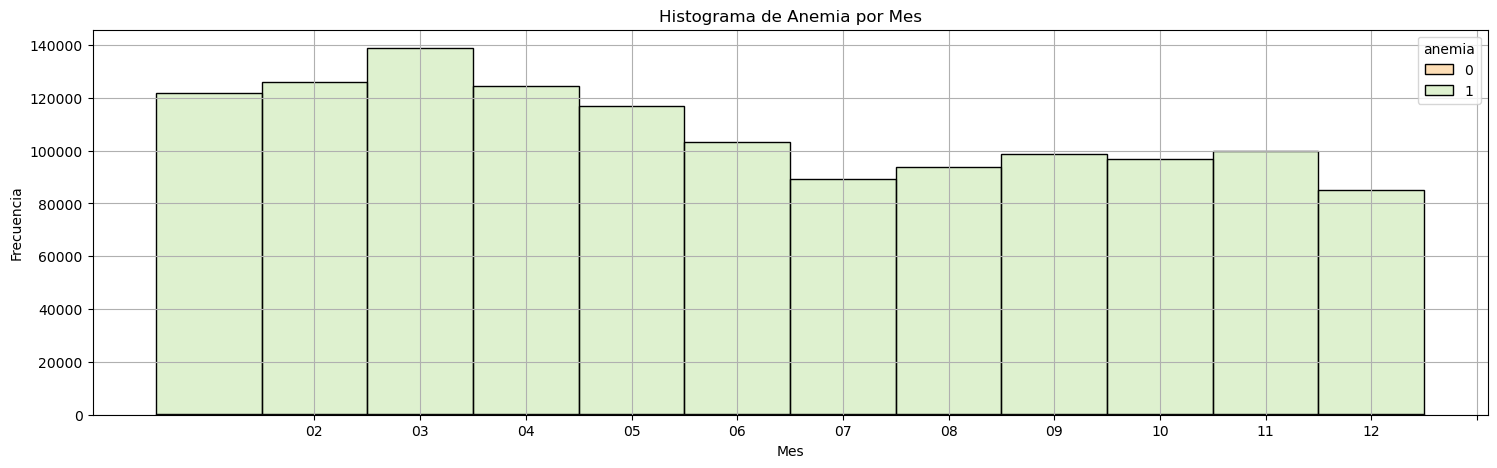

In [303]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 5))

# Ordenar los meses (asegurarse de que sean numéricos y estén en orden)
df_anemia_processed["mes"] = pd.Categorical(df_anemia_processed["mes"], 
                                            categories=sorted(df_anemia_processed["mes"].unique()), 
                                            ordered=True)

# Crear histograma separado por anemia
sns.histplot(data=df_anemia_processed, x="mes", hue="anemia", palette="Spectral", discrete=True)

# Personalización del gráfico
plt.xlabel("Mes")
plt.ylabel("Frecuencia")
plt.title("Histograma de Anemia por Mes")
plt.xticks(range(1, 13))  # Asegurar que se muestren los 12 meses
plt.grid(True)

# Mostrar gráfico
plt.show()

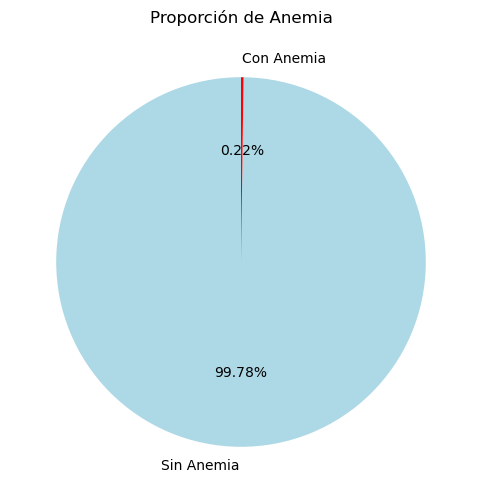

In [287]:
import matplotlib.pyplot as plt

# Contar casos con y sin anemia
conteo_anemia = df_anemia_processed["anemia"].value_counts()

# Etiquetas para el gráfico
labels = ["Sin Anemia", "Con Anemia"]

# Crear gráfico de pastel
plt.figure(figsize=(6, 6))
plt.pie(conteo_anemia, labels=labels, autopct="%.2f%%", colors=["lightblue", "red"], startangle=90)

# Título y mostrar gráfico
plt.title("Proporción de Anemia")
plt.show()

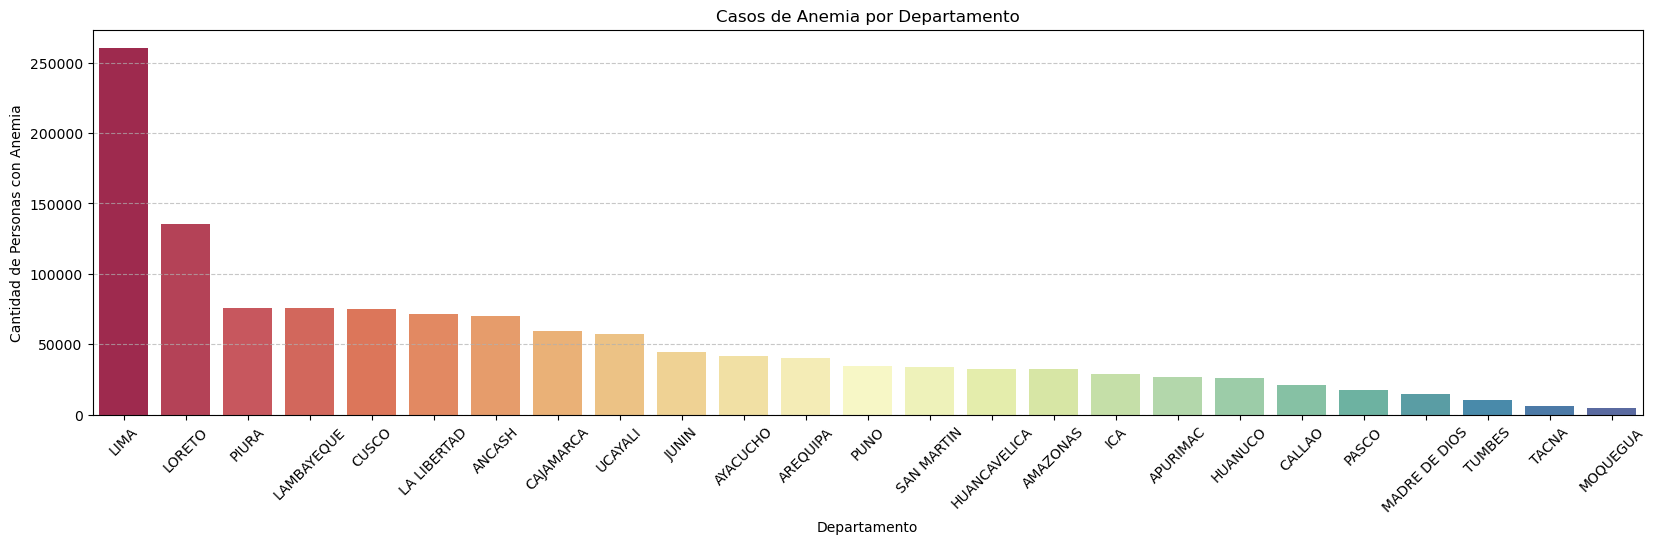

In [306]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar solo personas con anemia (asumiendo que 1 = tiene anemia)
df_anemia = df_anemia_processed[df_anemia_processed["anemia"] == 1]

# Contar casos de anemia por departamento
conteo_anemia_dpto = df_anemia["dpto"].value_counts()

# Crear el gráfico de barras
plt.figure(figsize=(20, 5))
sns.barplot(x=conteo_anemia_dpto.index, y=conteo_anemia_dpto.values, palette="Spectral")

# Personalización del gráfico
plt.xlabel("Departamento")
plt.ylabel("Cantidad de Personas con Anemia")
plt.title("Casos de Anemia por Departamento")
plt.xticks(rotation=45)  # Rotar etiquetas para mejor visibilidad
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Mostrar gráfico
plt.show()

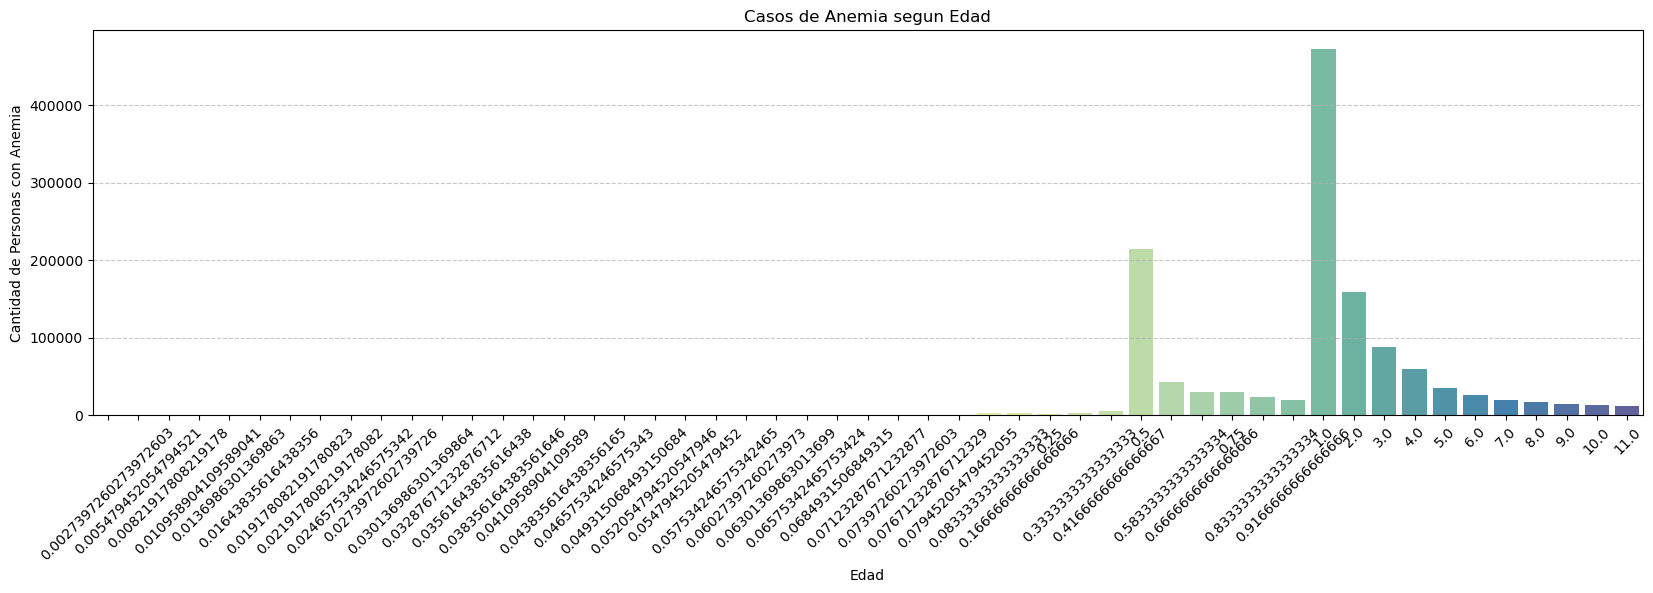

In [305]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar solo personas con anemia (asumiendo que 1 = tiene anemia)
df_anemia = df_anemia_processed[df_anemia_processed["anemia"] == 1]

# Contar casos de anemia por departamento
conteo_anemia_dpto = df_anemia["edad"].value_counts()

# Crear el gráfico de barras
plt.figure(figsize=(20, 5))
sns.barplot(x=conteo_anemia_dpto.index, y=conteo_anemia_dpto.values, palette="Spectral")

# Personalización del gráfico
plt.xlabel("Edad")
plt.ylabel("Cantidad de Personas con Anemia")
plt.title("Casos de Anemia segun Edad")
plt.xticks(rotation=45)  # Rotar etiquetas para mejor visibilidad
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Mostrar gráfico
plt.show()

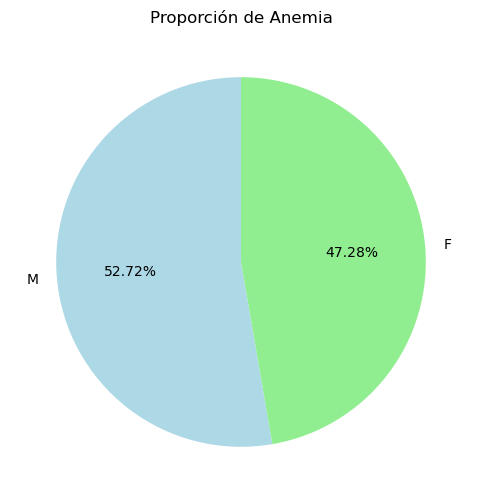

In [307]:
import matplotlib.pyplot as plt

# Contar casos con y sin anemia
conteo_anemia = df_anemia_processed["sexo"].value_counts()

# Etiquetas para el gráfico
labels = ["M", "F"]

# Crear gráfico de pastel
plt.figure(figsize=(6, 6))
plt.pie(conteo_anemia, labels=labels, autopct="%.2f%%", colors=["lightblue", "lightgreen"], startangle=90)

# Título y mostrar gráfico
plt.title("Proporción de Anemia")
plt.show()

## Identificamos variables categóricas

In [243]:
categorical_columns = df_anemia_processed.select_dtypes(object).columns
categorical_columns

Index(['mes', 'sexo', 'dpto'], dtype='object')

## Creamos lista por tipo de codificación

In [244]:
for cc in categorical_columns:
  print("*"*50)
  print(df_anemia_processed[cc].value_counts())

**************************************************
03    139112
02    126125
04    124814
01    122226
05    117382
06    103615
11    100024
09     98983
10     96891
08     94144
07     89327
12     85177
Name: mes, dtype: int64
**************************************************
M    684186
F    613634
Name: sexo, dtype: int64
**************************************************
LIMA             261381
LORETO           135932
PIURA             75907
LAMBAYEQUE        75647
CUSCO             75060
LA LIBERTAD       71621
ANCASH            69953
CAJAMARCA         59662
UCAYALI           57220
JUNIN             44827
AYACUCHO          41822
AREQUIPA          40045
PUNO              34769
SAN MARTIN        33687
HUANCAVELICA      32284
AMAZONAS          32186
ICA               29302
APURIMAC          26869
HUANUCO           26248
CALLAO            20849
PASCO             17204
MADRE DE DIOS     14438
TUMBES            10175
TACNA              6141
MOQUEGUA           4591
Name: dpto, dtype:

In [245]:
ordinal_cols = ['sexo','mes','dpto']
onehot_cols = list(set(categorical_columns) - set(ordinal_cols))
print(ordinal_cols,onehot_cols)

['sexo', 'mes', 'dpto'] []


## Creamos un transformer

In [246]:
import sklearn.compose
import sklearn.preprocessing
transformer = sklearn.compose.make_column_transformer(
    (sklearn.preprocessing.OrdinalEncoder(),ordinal_cols),
    (sklearn.preprocessing.OneHotEncoder(),onehot_cols),
    remainder='passthrough'
)
transformer

ColumnTransformer(remainder='passthrough',
                  transformers=[('ordinalencoder', OrdinalEncoder(),
                                 ['sexo', 'mes', 'dpto']),
                                ('onehotencoder', OneHotEncoder(), [])])

## Aplicamos el transformer a la variable categórica

In [247]:
data_transformed_df = (
    pd.DataFrame(
        transformer.fit_transform(df_anemia_processed),
        columns = transformer.get_feature_names_out(),
        index=df_anemia_processed.index
    )
)

data_transformed_df = data_transformed_df.rename(
    columns=lambda x: x.replace("ordinalencoder__", "").replace("onehotencoder__", "").replace("remainder__", "")
)

data_transformed_df

,sexo,mes,dpto,edad,anemia
0,1.0,10.0,11.0,4.0,1.0
1,1.0,10.0,11.0,4.0,1.0
2,0.0,4.0,11.0,3.0,1.0
3,0.0,1.0,14.0,2.0,1.0
4,1.0,10.0,16.0,4.0,1.0
...,...,...,...,...,...
1297815,0.0,7.0,14.0,6.0,1.0
1297816,1.0,1.0,10.0,9.0,1.0
1297817,0.0,2.0,14.0,1.0,1.0
1297818,0.0,3.0,14.0,1.0,1.0


In [249]:
corr_matrix = data_transformed_df.corr()
corr_class = corr_matrix['anemia']
corr_class.sort_values(ascending=False)

anemia    1.000000
sexo      0.001098
mes      -0.003116
dpto     -0.005255
edad     -0.040197
Name: anemia, dtype: float64

<Axes: >

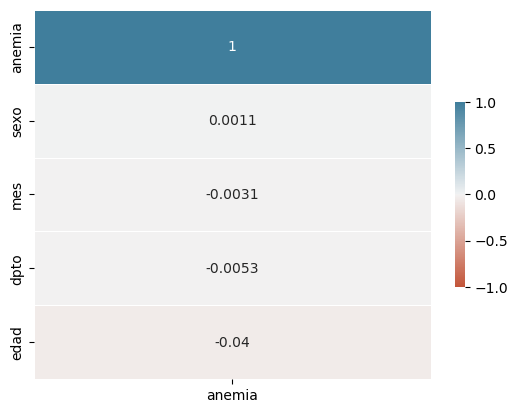

In [250]:
sns.heatmap(
    data=corr_class.sort_values(ascending=False).to_frame(),
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    annot=True
)

In [251]:
corr_filtered = corr_class[corr_class > 0.001]
cols = corr_filtered.index.tolist()
cols

['sexo', 'anemia']

In [257]:
X = data_transformed_df.drop(columns=['anemia','mes','dpto'])
y = data_transformed_df['anemia']

In [258]:
display(X)

,sexo,edad
0,1.0,4.0
1,1.0,4.0
2,0.0,3.0
3,0.0,2.0
4,1.0,4.0
...,...,...
1297815,0.0,6.0
1297816,1.0,9.0
1297817,0.0,1.0
1297818,0.0,1.0


## Aplicando Regresión Logística

In [259]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)
print(f'Accuracy : {accuracy:.2f}')


Accuracy : 1.00


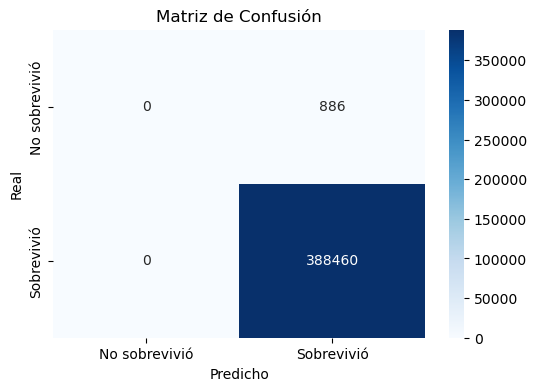

In [260]:
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No sobrevivió', 'Sobrevivió'], yticklabels=['No sobrevivió', 'Sobrevivió'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

In [261]:
from sklearn.preprocessing import MinMaxScaler

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)
print(f'Accuracy : {accuracy:.2f}')

Accuracy : 1.00


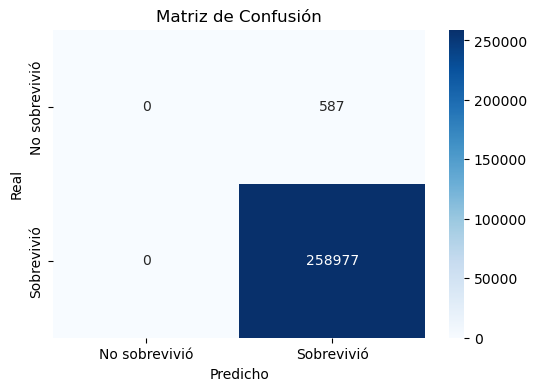

In [262]:
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No sobrevivió', 'Sobrevivió'], yticklabels=['No sobrevivió', 'Sobrevivió'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

## Aplicamos Árboles de Decisión

Accuracy TREE 1 : 0.9977385153565209


[Text(0.6999143835616438, 0.9545454545454546, 'x[1] <= 0.409\ngini = 0.004\nsamples = 1038256\nvalue = [2255, 1036001]'),
 Text(0.5002853881278538, 0.8636363636363636, 'x[1] <= 0.034\ngini = 0.003\nsamples = 926965\nvalue = [1468, 925497]'),
 Text(0.6000998858447488, 0.9090909090909092, 'True  '),
 Text(0.3159246575342466, 0.7727272727272727, 'x[1] <= 0.007\ngini = 0.025\nsamples = 9340\nvalue = [116, 9224]'),
 Text(0.1797945205479452, 0.6818181818181818, 'x[1] <= 0.005\ngini = 0.055\nsamples = 749\nvalue = [21, 728]'),
 Text(0.09474885844748858, 0.5909090909090909, 'x[0] <= 0.5\ngini = 0.038\nsamples = 561\nvalue = [11, 550]'),
 Text(0.0547945205479452, 0.5, 'x[1] <= 0.004\ngini = 0.022\nsamples = 271\nvalue = [3, 268]'),
 Text(0.0365296803652968, 0.4090909090909091, 'x[1] <= 0.001\ngini = 0.016\nsamples = 244\nvalue = [2, 242]'),
 Text(0.0273972602739726, 0.3181818181818182, 'x[1] <= 0.001\ngini = 0.029\nsamples = 136\nvalue = [2, 134]'),
 Text(0.0182648401826484, 0.22727272727272727

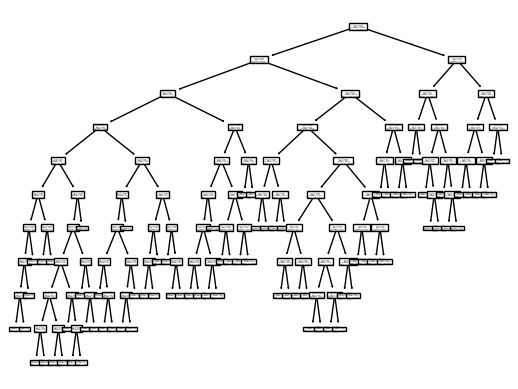

In [269]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn import tree
import graphviz

tree1 = DecisionTreeClassifier()
tree1.fit(X_train,y_train)
y_pred = tree1.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
print(f'Accuracy TREE 1 : {accuracy}')

tree.plot_tree(tree1)

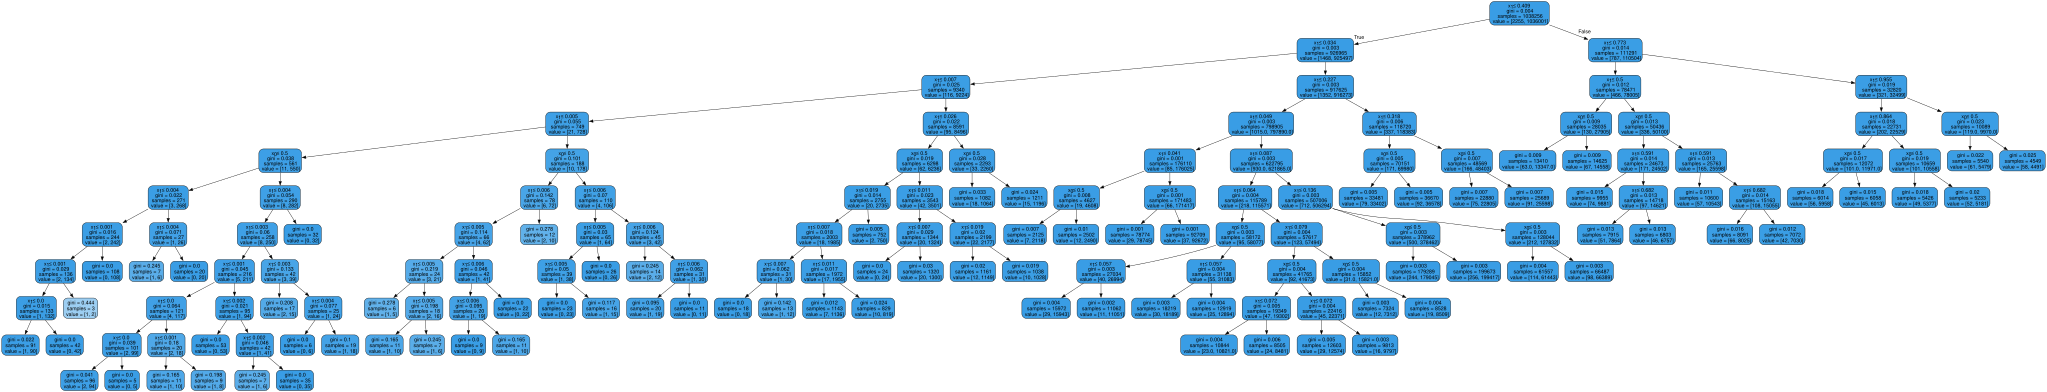

In [270]:
import graphviz
dot_data = tree.export_graphviz(tree1, out_file=None, 
                     #feature_names=iris.feature_names,  
                     #class_names=iris.target_names,  
                     filled=True, rounded=True,  
                     special_characters=True)  
graph = graphviz.Source(dot_data)  
graph 

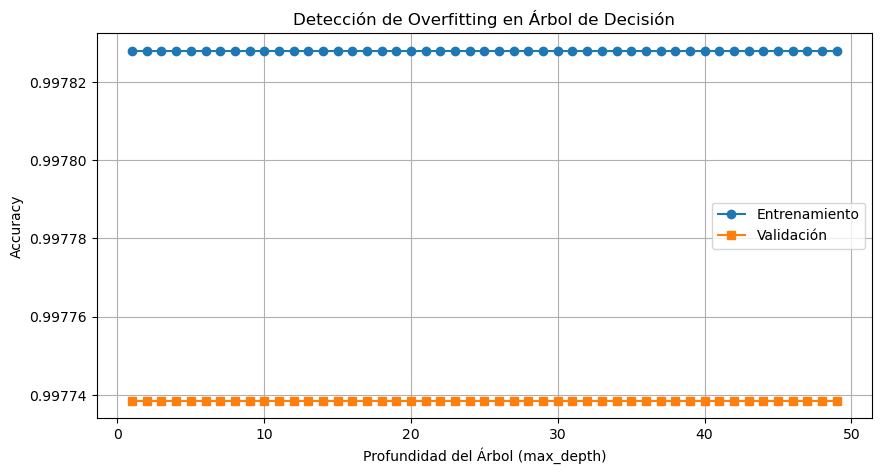

In [271]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Datos (usamos X, y de tu dataset)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

train_scores = []
val_scores = []
max_depths = range(1, 50)  # Profundidades de 1 a 20

for depth in max_depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    # Evaluamos en los conjuntos de entrenamiento y validación
    train_acc = accuracy_score(y_train, model.predict(X_train))
    val_acc = accuracy_score(y_val, model.predict(X_val))

    train_scores.append(train_acc)
    val_scores.append(val_acc)

# Graficamos las curvas de accuracy
plt.figure(figsize=(10, 5))
plt.plot(max_depths, train_scores, label="Entrenamiento", marker='o')
plt.plot(max_depths, val_scores, label="Validación", marker='s')
plt.xlabel("Profundidad del Árbol (max_depth)")
plt.ylabel("Accuracy")
plt.title("Detección de Overfitting en Árbol de Decisión")
plt.legend()
plt.grid(True)
plt.show()